In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, minimize

from readrbdata import load

import matplotlib.pyplot as plt

from fittingutils import *
from readrbdata import transform

%matplotlib widget

In [2]:
spike_data = []

In [3]:
sat = load(sat=True, mag=False)
uns = load(sat=False, mag=False)

# this makes the two signals agree a lot more, very annoyingly...
def loss(offset):
    diff = sat.signal - np.interp(sat.frequency + offset, uns.frequency, uns.signal, left=np.nan, right=np.nan)
    diff = diff[np.isfinite(diff)]
    return np.sum(diff**2) / len(diff)

offset_opt_res = minimize(loss, 0.)
offset_opt_res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 3.5838388602146165
        x: [-1.871e-02]
      nit: 12
      jac: [ 0.000e+00]
 hess_inv: [[ 1.912e-08]]
     nfev: 76
     njev: 38

In [4]:
# whatever
sat.frequency += offset_opt_res.x[0]

In [5]:
diff_freq = sat.frequency

diff_signal = sat.signal - np.interp(diff_freq, uns.frequency, uns.signal, left=np.nan, right=np.nan)

ok_idx = np.isfinite(diff_signal)

diff_signal = diff_signal[ok_idx]
diff_freq = diff_freq[ok_idx]

In [6]:
sat.frequency[0], uns.frequency[0]

(-0.231930678031879, -0.27870648334215753)

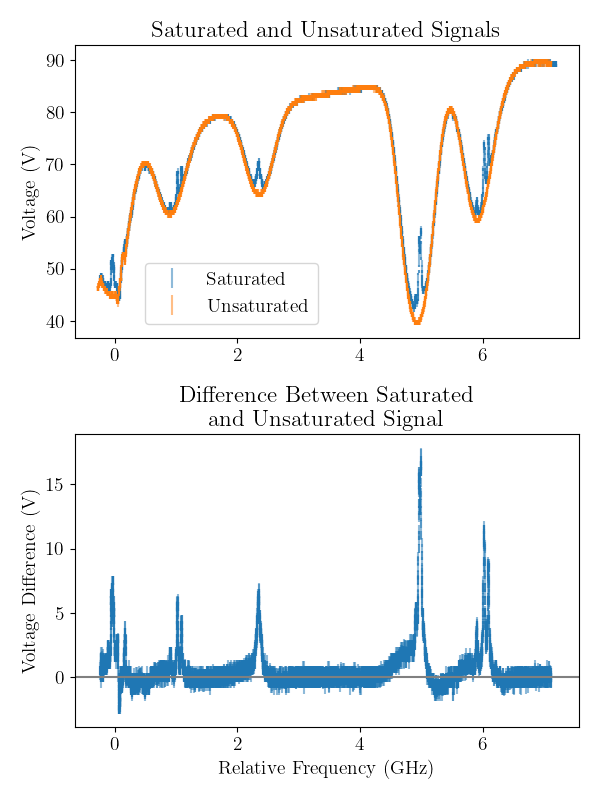

In [7]:
fig, (sig_ax, diff_ax) = plt.subplots(nrows=2, sharex=True, figsize=(6, 8))
# plt.rcParams.update({'font.size': 12})

sig_ax.set_title('Saturated and Unsaturated Signals')
sig_ax.errorbar(sat.frequency, sat.signal, yerr=0.25, alpha=0.5, label='Saturated', ls='')
sig_ax.errorbar(uns.frequency, uns.signal, yerr=0.25, alpha=0.5, label='Unsaturated', ls='')
sig_ax.set_ylabel('Voltage (V)')
# sig_ax.set_xlabel('Relative Frequency (GHz)')
sig_ax.xaxis.set_tick_params(labelbottom=True)
sig_ax.legend(loc=(0.14, 0.05))

diff_ax.set_title('Difference Between Saturated\nand Unsaturated Signal')
diff_ax.errorbar(diff_freq, diff_signal, yerr=np.sqrt(2)*0.25, alpha=0.5, ls='')
diff_ax.axhline(0., color="gray")
diff_ax.set_xlabel('Relative Frequency (GHz)')
diff_ax.set_ylabel('Voltage Difference (V)')
# diff_ax.legend()
fig.tight_layout()


# Fit Ugly One

Fitting this one all at once just because they're so close together

In [8]:
def triple_lorentzian(
        x, 
        x00, g0, a0, 
        x01, g1, a1, 
        x02, g2, a2, 
        offset, offset_slope
):
    return Lorentzian(x, x00, g0, a0, 0.) + Lorentzian(x, x01, g1, a1, 0.) + Lorentzian(x, x02, g2, a2, 0.) + offset + x*offset_slope

len(p0) = 11
fit params:
[ 4.90695139e+00  9.55428563e-03  2.93833849e+00  4.96131476e+00
  1.14241796e-02  1.10102192e+01  4.98895453e+00  1.49588539e-02
  1.36421494e+01  2.01925633e+01 -3.76940937e+00]
cov:
[[ 1.66043617e-07  4.74745631e-09 -5.19821361e-07 -4.34396687e-10
  -1.35676534e-08 -2.18825612e-07 -3.11596308e-09  2.21527196e-09
   3.12646988e-06  3.11847901e-05 -6.17400644e-06]
 [ 4.74745631e-09  4.52033513e-07 -4.82313714e-05 -2.91223232e-09
  -4.02579463e-08 -8.58631309e-07 -9.09482072e-09  1.68148888e-08
   1.33006305e-05 -1.66456039e-04  3.20441484e-05]
 [-5.19821361e-07 -4.82313714e-05  1.54923857e-02 -5.33531376e-07
   2.51627634e-07  5.97197659e-04  7.07651776e-08  4.76769782e-07
   3.81654087e-04 -3.26957409e-03  5.92443579e-04]
 [-4.34396687e-10 -2.91223232e-09 -5.33531376e-07  2.66112558e-08
   2.18672824e-08  8.05660161e-06  1.63164236e-08 -2.12711366e-08
  -8.90327540e-06 -2.09974729e-05  4.41710423e-06]
 [-1.35676534e-08 -4.02579463e-08  2.51627634e-07  2.18672

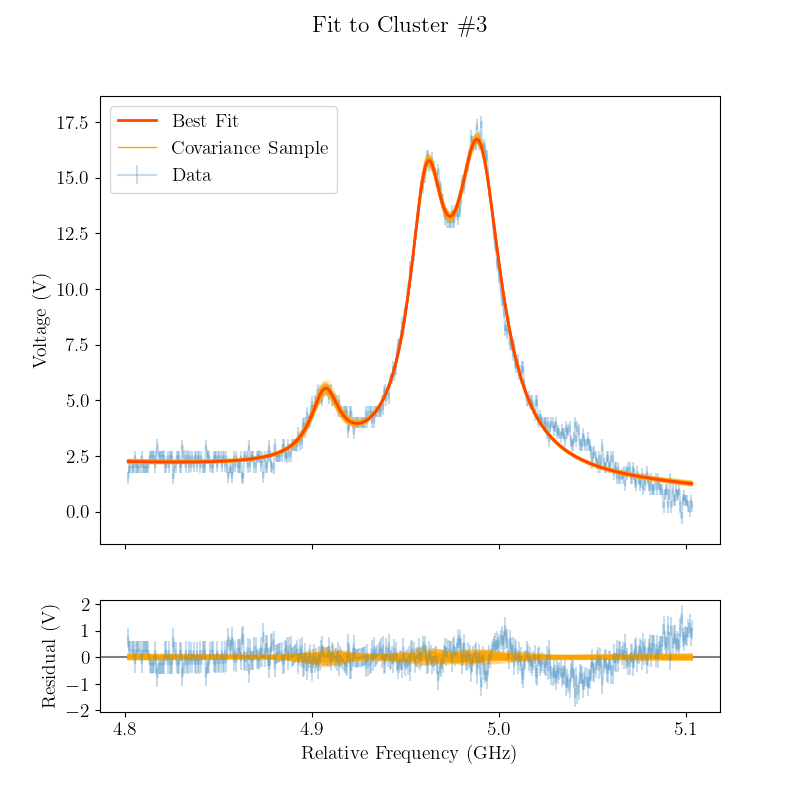

In [9]:
x_low = .034 # remnant from when i worked in time units i am too lazy to fix
x_high = .038
cluster_n = 2

# MAKE PLOTS
# fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(15, 7))
fig, (fit_data_ax, fit_res_ax) = plt.subplots(2, 1, sharex=True, height_ratios=[4, 1], figsize=(8, 8))

# ESTABLISH INITIAL GUESSES
spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

x = diff_freq[spidx]
y = diff_signal[spidx]

baseline_slope_guess = (y[-1] - y[0]) / (x[-1] - x[0])

# p0 = [
#     4.92546154e+00,
#     9.86185753e-03,  
#     3.04749742e+00,  
    
#     4.97997906e+00,
#     1.10517537e-02,
#     1.12703114e+01,
    
#     5.00778981e+00,
#     1.48773556e-02,
#     1.39587998e+01,
    
#     7.11786513e+01,
#     -1.40941661e+01
# ]

p0 = [
    4.90660884e+00,
    9.57678660e-03,
    2.93350539e+00,
    
    4.96096085e+00,
    1.14178255e-02,
    1.10103184e+01,
    
    4.98860413e+00,
    1.49472351e-02,
    1.36454183e+01,
    
    1.91435783e+01,
    -3.55652205e+00
]
print(f"{len(p0) = }")

# guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
# guess_data_ax.plot(x, triple_lorentzian(x, *p0), zorder=10, color='blue', label='Model with First Guess')

# guess_data_ax.set_title('Fit Initial Guess')
# guess_data_ax.set_ylabel('Voltage (V)')
# guess_data_ax.legend()

# residuals = triple_lorentzian(x, *p0) - y

# guess_res_ax.axhline(0., color='gray')
# guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
# guess_res_ax.set_ylabel('Residual (V)')
# # guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))

fit_params, cov = curve_fit(triple_lorentzian, x, y, p0, np.sqrt(2)*0.25)
print(f"fit params:\n{fit_params}")
print(f"cov:\n{cov}")

fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25, label='Data')
fit_data_ax.plot(x, triple_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
data_y_lims = fit_data_ax.set_ylim()

random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
for fit_sample in random_fit_samples:
    fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, alpha=0.3)
fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Covariance Sample')

fit_data_ax.legend()

fit_data_ax.set_ylim(data_y_lims)
# fit_data_ax.set_title('Resulting Fit')
fit_data_ax.set_ylabel('Voltage (V)')

residuals = triple_lorentzian(x, *fit_params) - y

fit_res_ax.axhline(0., color='gray')
fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
for fit_sample in random_fit_samples:
    fit_res_ax.plot(x, triple_lorentzian(x, *fit_sample) - triple_lorentzian(x, *fit_params), c='orange', alpha=0.3)

fit_res_ax.set_ylabel('Residual (V)')
fit_res_ax.set_xlabel('Relative Frequency (GHz)')

fig.suptitle(f'Fit to Cluster \\#{cluster_n + 1}')

red_chi2 = np.sum((residuals / (np.sqrt(2)*.25))**2) / (len(residuals) - 11)
print(f"{red_chi2 = :.4g}")

for i in range(3):
    this_spike = {
        "center_freq": fit_params[0 + i*3],
        "e_center_freq": np.sqrt(np.diag(cov))[0 + i*3],
        "amplitude": fit_params[2 + i*3],
        "cluster_id": cluster_n,
        "red_chi2": red_chi2
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")


plt.locator_params(nbins=5)


In [10]:
def red_lorentzian(x, center, gamma, amplitude, baseline, baseline_slope):
    return Lorentzian(x, center, gamma, amplitude, baseline) + baseline_slope*x

In [ ]:
def fit_spike(x_low, x_high, cluster_n, spike_n=0):
    # MAKE PLOTS
    # fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(15, 7))
    fig, (fit_data_ax, fit_res_ax) = plt.subplots(2, 1, sharex=True, height_ratios=[4, 1], figsize=(8, 8))

    # ESTABLISH INITIAL GUESSES
    spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

    x = diff_freq[spidx]
    y = diff_signal[spidx]

    center_guess = x[np.argmax(diff_signal[spidx])]
    slope_guess = (y[-1] - y[0]) / (x[-1] - x[0])

    p0 = [
        center_guess,
        Lorentzian.guess_gamma(x, y),
        np.max(y) #- (slope_guess*(center_guess - x[0]) + y[0]),
        y[0] #- slope_guess*x[0],
        # slope_guess
    ]
    print(f"{p0 = }")

    # guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
    # guess_data_ax.plot(x, red_lorentzian(x, *p0), zorder=10, color='blue')

    # guess_data_ax.axvline(p0[0], label='x0 guess', c='red', alpha=0.5)
    # guess_data_ax.plot([p0[0] - p0[1], p0[0] + p0[1]], [(p0[2] + p0[3] + slope_guess*x[0])/2, (p0[2] + p0[3] + slope_guess*x[0])/2], color='green', alpha=0.5, label='FWHM guess')
    # # guess_data_ax.axhline(p0[2] + p0[3] + slope_guess*x[0], label='amplitude guess', c='red', alpha=0.5)
    # guess_data_ax.axline(slope_guess*(center_guess - x[0]) + y[0], slope=slope_guess)
    # guess_data_ax.axhline(p0[3] + slope_guess*x[0], label='baseline guess', c='red', alpha=0.5)

    # guess_data_ax.set_title('Fit Initial Guess')
    # guess_data_ax.set_ylabel('Voltage (V)')
    # guess_data_ax.legend()

    # residuals = red_lorentzian(x, *p0) - y

    # guess_res_ax.axhline(0., color='gray')
    # guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    # guess_res_ax.set_ylabel('Residual (V)')
    # guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))
    
    fit_params, cov = curve_fit(red_lorentzian, x, y, p0, np.sqrt(2)*0.25)
    print(f"fit params:\n{fit_params}")
    print(f"cov:\n{cov}")

    fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25, label='Data')
    fit_data_ax.plot(x, red_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
    data_y_lims = fit_data_ax.set_ylim()

    random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
    for fit_sample in random_fit_samples:
        fit_data_ax.plot(x, red_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5)
    fit_data_ax.plot(x, red_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Covariance Sample')
    
    fit_data_ax.set_ylabel('Voltage Difference (V)')
    fit_data_ax.legend()

    fit_data_ax.set_ylim(data_y_lims)
    # fit_data_ax.set_title('Resulting Fit')

    residuals = red_lorentzian(x, *fit_params) - y

    fit_res_ax.axhline(0., color='gray')
    fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    for fit_sample in random_fit_samples:
        fit_res_ax.plot(x, red_lorentzian(x, *fit_sample) - red_lorentzian(x, *fit_params), c='orange')

    fit_res_ax.set_xlabel("Relative Frequency (GHz)")
    fit_res_ax.set_ylabel("Residual (V)")

    fig.suptitle(f'Fit to Cluster \\#{cluster_n + 1}, Spike \\#{spike_n + 1}')
    
    red_chi2 = np.sum((residuals / (np.sqrt(2)*.25))**2) / (len(residuals) - 5)

    this_spike = {
        "center_freq": fit_params[0],
        "e_center_freq": np.sqrt(np.diag(cov))[0],
        "amplitude": fit_params[2],
        "cluster_id": cluster_n,
        "red_chi2": red_chi2
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")
    plt.locator_params(nbins=5)
    
    print(f"{red_chi2 = :.4g}")

p0 = [0.9035292207201749, 0.005013544351368693, 1.7898761065813626, -1.2743893550267684, 1.6430163124797963]
fit params:
[ 0.90899876  0.01050412  1.67485904  0.32649867 -0.08630675]
cov:
[[ 1.94661731e-07  3.09812776e-09  1.12047779e-07  4.69764280e-05
  -5.18976750e-05]
 [ 3.09812776e-09  6.72082976e-07 -2.29814227e-05 -3.43767637e-06
  -1.48206979e-05]
 [ 1.12047779e-07 -2.29814227e-05  4.83944068e-03  1.49248703e-04
  -5.79550174e-04]
 [ 4.69764280e-05 -3.43767637e-06  1.49248703e-04  2.04996932e-01
  -2.25493881e-01]
 [-5.18976750e-05 -1.48206979e-05 -5.79550174e-04 -2.25493881e-01
   2.49200795e-01]]
this_spike = {'center_freq': 0.9089987568838591, 'e_center_freq': 0.00044120486261292857, 'amplitude': 1.6748590394551266, 'cluster_id': 0, 'red_chi2': 0.6149677190782411}
len(spike_data) = 4
red_chi2 = 0.615


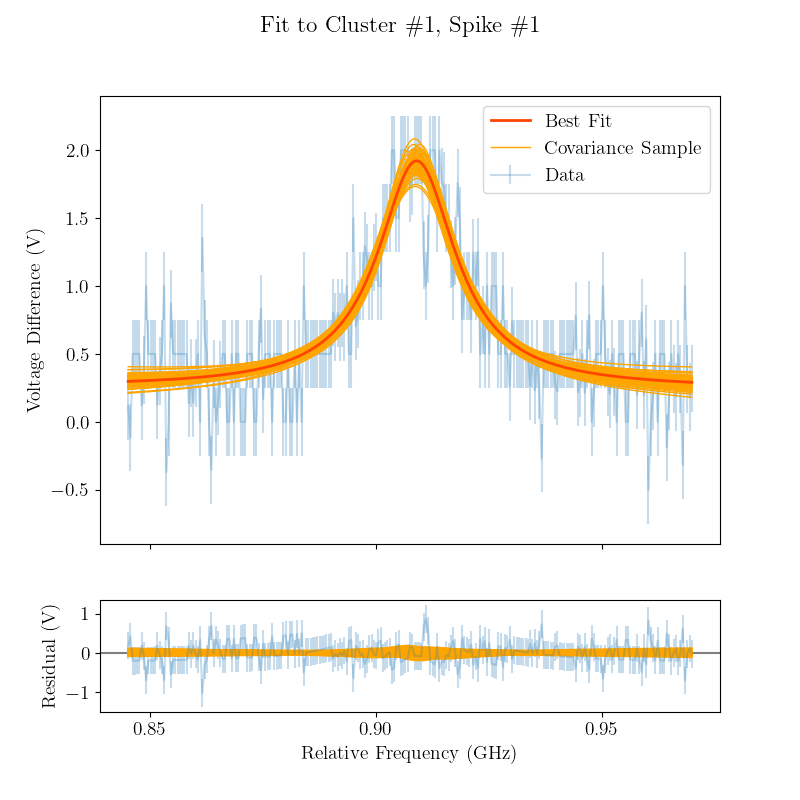

In [12]:
fit_spike(-.022, -.02, 0)

p0 = [1.0252292992683922, 0.010427241960593081, 5.227617502457505, -2.8330208887450343, 3.6199218896053833]
fit params:
[ 1.02417473  0.01142445  5.7068598  -0.43523807  0.62012217]
cov:
[[ 2.02505845e-08  6.84037736e-09  1.33901595e-06  5.92358566e-05
  -5.96714865e-05]
 [ 6.84037736e-09  9.96066148e-08  2.78587267e-07  1.17000014e-04
  -1.28729986e-04]
 [ 1.33901595e-06  2.78587267e-07  5.56450153e-03  2.39560176e-02
  -2.54866196e-02]
 [ 5.92358566e-05  1.17000014e-04  2.39560176e-02  1.00094495e+00
  -1.00953178e+00]
 [-5.96714865e-05 -1.28729986e-04 -2.54866196e-02 -1.00953178e+00
   1.02048562e+00]]
this_spike = {'center_freq': 1.0241747255421614, 'e_center_freq': 0.00014230454831016403, 'amplitude': 5.706859804595812, 'cluster_id': 0, 'red_chi2': 0.5876430391880423}
len(spike_data) = 5
red_chi2 = 0.5876


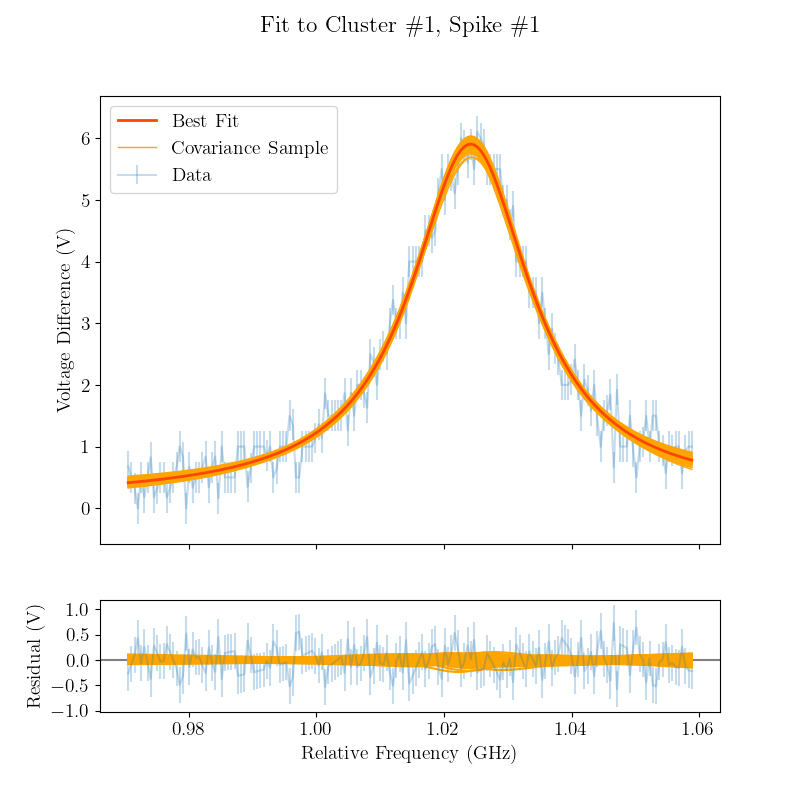

In [13]:
fit_spike(-.02, -.01860, 0)

p0 = [1.0864876935224284, 0.009736903119575202, 3.8070329053281897, -7.040972684078467, 7.11829487334237]
fit params:
[ 1.08993409  0.01115348  4.16061795  1.25471054 -1.03706178]
cov:
[[ 5.50594942e-08 -1.58353549e-08 -2.76022636e-06  2.05382829e-04
  -1.85122954e-04]
 [-1.58353549e-08  3.01267782e-07  9.08818204e-06 -3.13850173e-04
   2.52039918e-04]
 [-2.76022636e-06  9.08818204e-06  9.10099629e-03 -5.27687805e-02
   4.39647074e-02]
 [ 2.05382829e-04 -3.13850173e-04 -5.27687805e-02  3.17746124e+00
  -2.85109378e+00]
 [-1.85122954e-04  2.52039918e-04  4.39647074e-02 -2.85109378e+00
   2.56315301e+00]]
this_spike = {'center_freq': 1.0899340897056944, 'e_center_freq': 0.00023464759583438426, 'amplitude': 4.160617946043288, 'cluster_id': 0, 'red_chi2': 0.787701974901933}
len(spike_data) = 6
red_chi2 = 0.7877


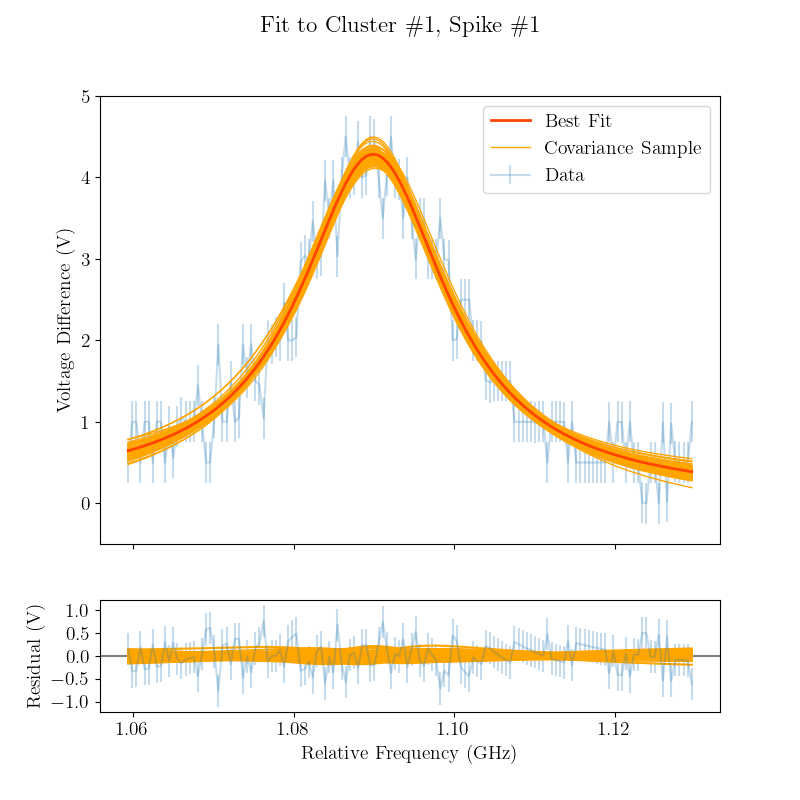

In [14]:
fit_spike(-.01860, -.01750, 0)

p0 = [2.3457897276854633, 0.02507011999312847, 6.777556550563416, 2.3107517991859092, -0.8902368038800352]
fit params:
[ 2.34656562  0.03781662  5.8618228   3.66291399 -1.53095746]
cov:
[[ 8.68405215e-08  3.97014990e-09  1.13152143e-07  7.96780347e-06
  -3.49491477e-06]
 [ 3.97014990e-09  2.73926081e-07 -1.12804077e-05  6.43814407e-06
  -5.05185228e-06]
 [ 1.13152143e-07 -1.12804077e-05  2.05584270e-03  2.56045620e-04
  -1.49803889e-04]
 [ 7.96780347e-06  6.43814407e-06  2.56045620e-04  2.27490073e-02
  -9.88335668e-03]
 [-3.49491477e-06 -5.05185228e-06 -1.49803889e-04 -9.88335668e-03
   4.34346038e-03]]
this_spike = {'center_freq': 2.346565620976609, 'e_center_freq': 0.00029468715867877733, 'amplitude': 5.861822802202818, 'cluster_id': 1, 'red_chi2': 0.8514924697768539}
len(spike_data) = 7
red_chi2 = 0.8515


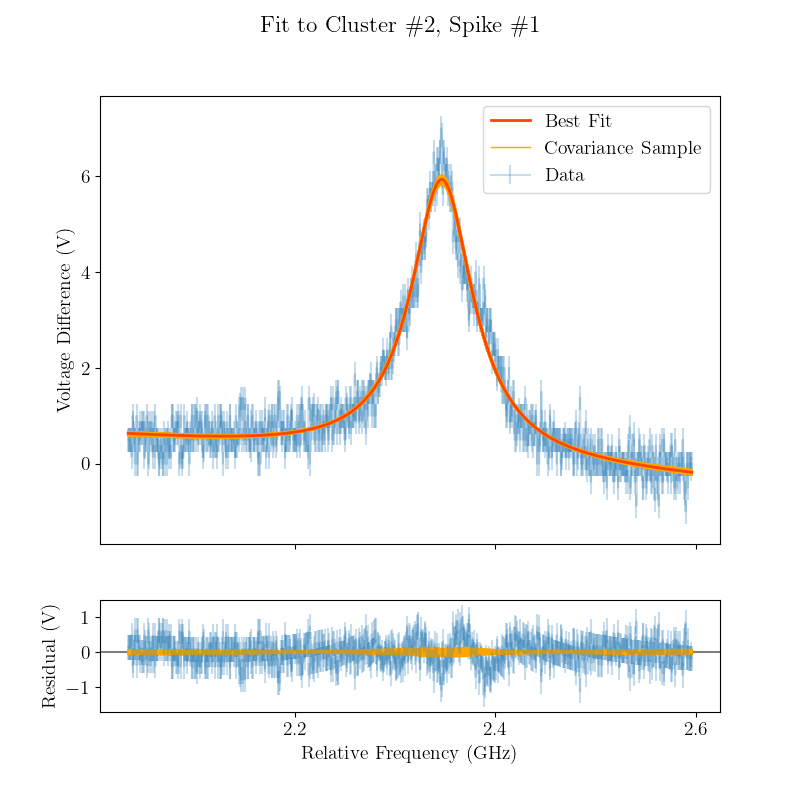

In [15]:
fit_spike(-.004, .004, 1)

p0 = [5.900832970531756, 0.012290860568302975, 3.571329753781127, -40.98926948875326, 7.077222466430725]
fit params:
[ 5.90197386e+00  1.14118643e-02  3.29716759e+00 -1.47560497e+01
  2.62032349e+00]
cov:
[[ 8.29166102e-08  2.85170934e-09  2.30105728e-07  3.46319231e-04
  -5.87428172e-05]
 [ 2.85170934e-09  3.15794446e-07 -1.43304586e-05  1.37737021e-04
  -2.63176128e-05]
 [ 2.30105728e-07 -1.43304586e-05  6.77467204e-03  1.17239033e-02
  -2.13577253e-03]
 [ 3.46319231e-04  1.37737021e-04  1.17239033e-02  1.71684103e+01
  -2.91212207e+00]
 [-5.87428172e-05 -2.63176128e-05 -2.13577253e-03 -2.91212207e+00
   4.94011926e-01]]
this_spike = {'center_freq': 5.901973862082606, 'e_center_freq': 0.00028795244436001136, 'amplitude': 3.2971675861677068, 'cluster_id': 3, 'red_chi2': 0.7391277136999828}
len(spike_data) = 8
red_chi2 = 0.7391


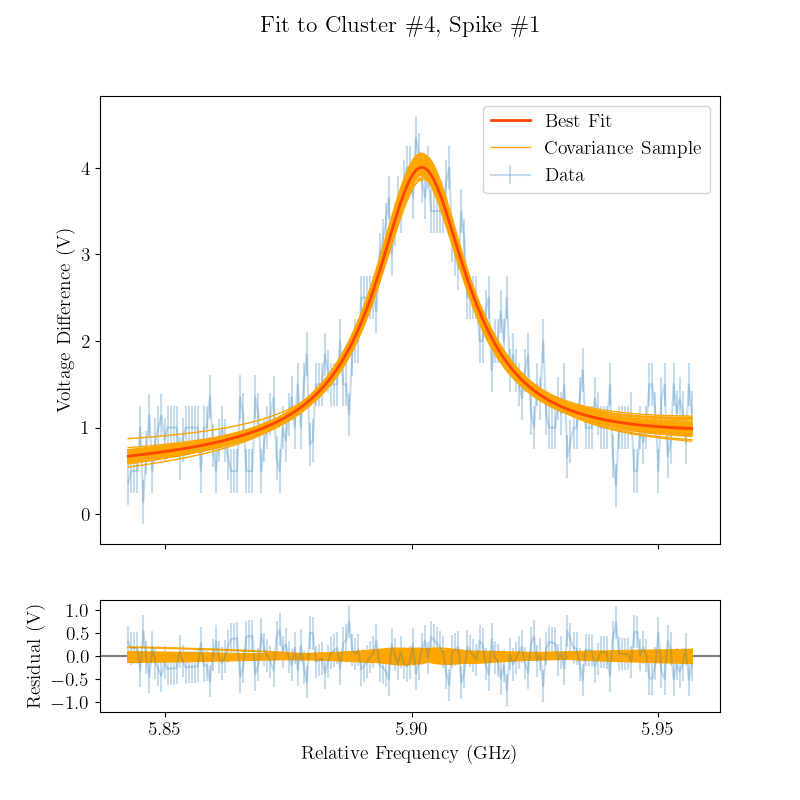

In [16]:
fit_spike(.0477, .0492, 3)

p0 = [6.022061474116377, 0.01632943256479491, 9.516361633758445, -95.95204751648964, 16.316329297887]
fit params:
[ 6.02072244e+00  1.40712922e-02  1.05230490e+01 -3.88628664e+01
  6.62371330e+00]
cov:
[[ 1.30146255e-08  4.85139446e-09  1.31212943e-06  2.30019777e-04
  -3.85219827e-05]
 [ 4.85139446e-09  6.28410881e-08 -6.28399418e-07  6.36824166e-04
  -1.08005695e-04]
 [ 1.31212943e-06 -6.28399418e-07  8.03302551e-03  1.75529799e-01
  -2.96241448e-02]
 [ 2.30019777e-04  6.36824166e-04  1.75529799e-01  2.82553512e+01
  -4.73511059e+00]
 [-3.85219827e-05 -1.08005695e-04 -2.96241448e-02 -4.73511059e+00
   7.93589266e-01]]
this_spike = {'center_freq': 6.020722438795966, 'e_center_freq': 0.00011408166145977445, 'amplitude': 10.523048950637808, 'cluster_id': 3, 'red_chi2': 0.8907825370088336}
len(spike_data) = 9
red_chi2 = 0.8908


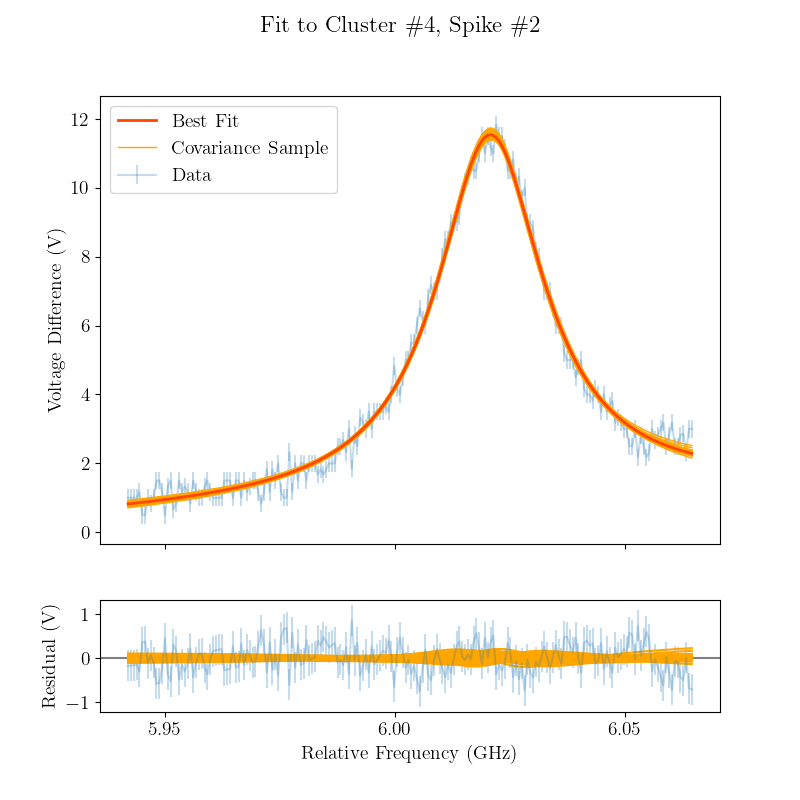

In [17]:
fit_spike(.04900, .0506, 3, spike_n=1)

p0 = [6.091134788612243, 0.012961653522375993, 6.297011233029513, 57.00326559275974, -8.914640491506937]
fit params:
[ 6.09070558e+00  1.20420111e-02  7.70105196e+00  7.95392391e+01
 -1.28648453e+01]
cov:
[[ 2.34885567e-08 -7.24420907e-09 -2.15093077e-06  7.58778901e-04
  -1.24117148e-04]
 [-7.24420907e-09  1.28076476e-07  6.47851290e-06 -1.13619778e-03
   1.81877210e-04]
 [-2.15093077e-06  6.47851290e-06  1.14101066e-02 -3.36136664e-01
   5.41964833e-02]
 [ 7.58778901e-04 -1.13619778e-03 -3.36136664e-01  1.02134168e+02
  -1.66964675e+01]
 [-1.24117148e-04  1.81877210e-04  5.41964833e-02 -1.66964675e+01
   2.72966486e+00]]
this_spike = {'center_freq': 6.0907055750495065, 'e_center_freq': 0.000153259768705463, 'amplitude': 7.701051958069304, 'cluster_id': 3, 'red_chi2': 0.8882255601014079}
len(spike_data) = 10
red_chi2 = 0.8882


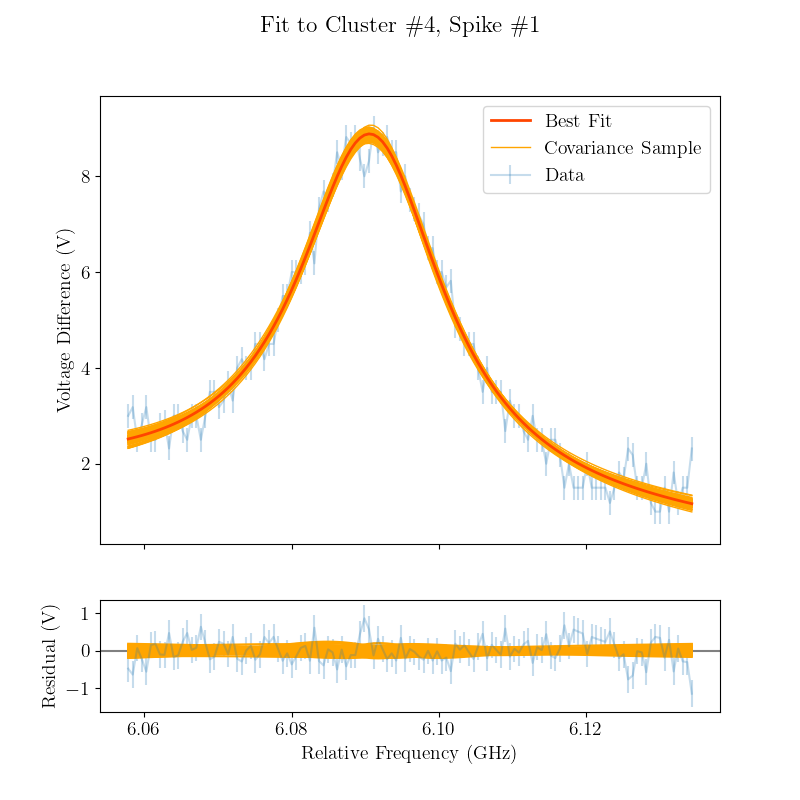

In [18]:
fit_spike(.0505, .0515, 3)

In [19]:
df = pd.DataFrame(spike_data).sort_values('center_freq').reset_index(drop=True)
df

,center_freq,e_center_freq,amplitude,cluster_id,red_chi2
0,0.908999,0.000441,1.674859,0,0.614968
1,1.024175,0.000142,5.706860,0,0.587643
2,1.089934,0.000235,4.160618,0,0.787702
3,2.346566,0.000295,5.861823,1,0.851492
4,4.906951,0.000407,2.938338,2,1.522918
5,4.961315,0.000163,11.010219,2,1.522918
6,4.988955,0.000171,13.642149,2,1.522918
7,5.901974,0.000288,3.297168,3,0.739128
8,6.020722,0.000114,10.523049,3,0.890783
9,6.090706,0.000153,7.701052,3,0.888226


In [20]:
df.to_csv('sas_spike_data.csv', index=False)

In [21]:
df.to_latex('sas_spike_data.tex')

In [22]:
for i in range(1, len(df)):
    diff = df['center_freq'].iloc[i] - df['center_freq'].iloc[i - 1]
    err = np.sqrt(df['e_center_freq'].iloc[i]**2 + df['e_center_freq'].iloc[i - 1]**2)
    print(f"{diff:.5f}\t{err:.2g}")

0.11518	0.00046
0.06576	0.00027
1.25663	0.00038
2.56039	0.0005
0.05436	0.00044
0.02764	0.00024
0.91302	0.00033
0.11875	0.00031
0.06998	0.00019


In [27]:
for val in df['red_chi2']: print(f"{val:.4g}")

0.615
0.5876
0.7877
0.8515
1.523
1.523
1.523
0.7391
0.8908
0.8882
